
===== MultinomialNB =====
              precision    recall  f1-score   support

           0      0.937     0.944     0.940      4696
           1      0.938     0.930     0.934      4284

    accuracy                          0.937      8980
   macro avg      0.937     0.937     0.937      8980
weighted avg      0.937     0.937     0.937      8980



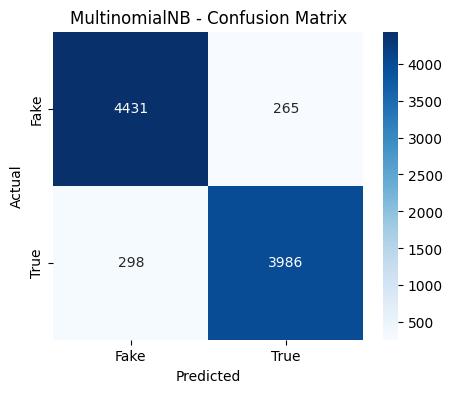

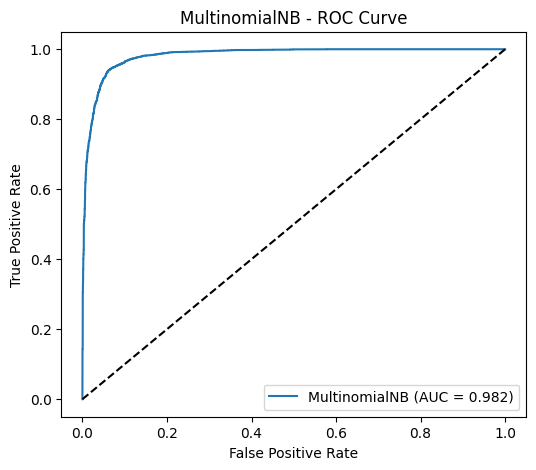


===== LogisticRegression =====
              precision    recall  f1-score   support

           0      0.991     0.983     0.987      4696
           1      0.982     0.991     0.986      4284

    accuracy                          0.987      8980
   macro avg      0.987     0.987     0.987      8980
weighted avg      0.987     0.987     0.987      8980



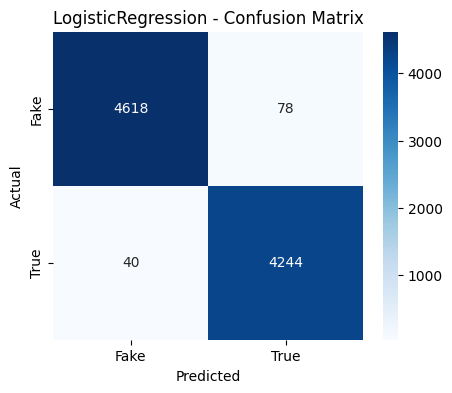

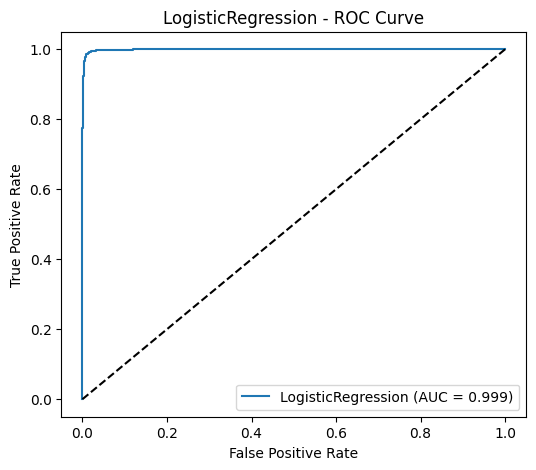


===== LinearSVM =====
              precision    recall  f1-score   support

           0      0.996     0.994     0.995      4696
           1      0.994     0.995     0.995      4284

    accuracy                          0.995      8980
   macro avg      0.995     0.995     0.995      8980
weighted avg      0.995     0.995     0.995      8980



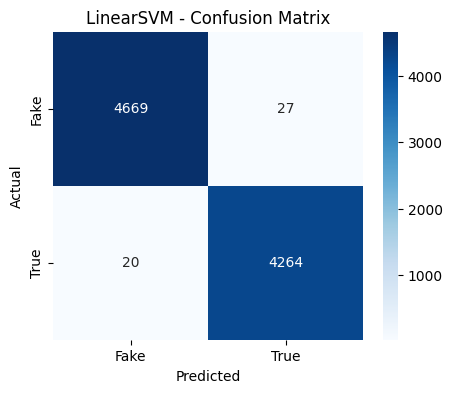

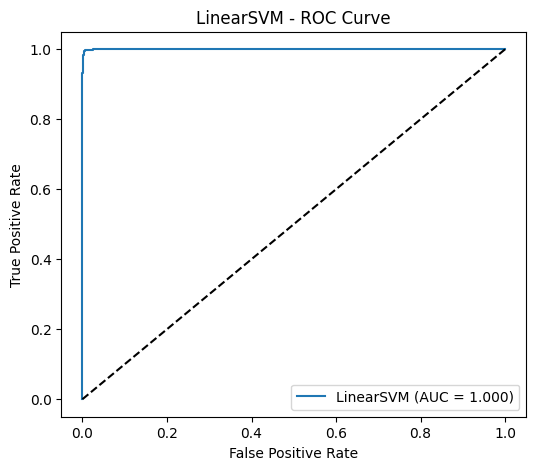


===== RandomForest =====
              precision    recall  f1-score   support

           0      0.998     0.998     0.998      4696
           1      0.997     0.998     0.998      4284

    accuracy                          0.998      8980
   macro avg      0.998     0.998     0.998      8980
weighted avg      0.998     0.998     0.998      8980



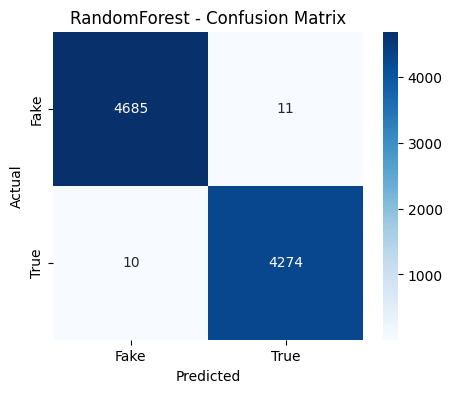

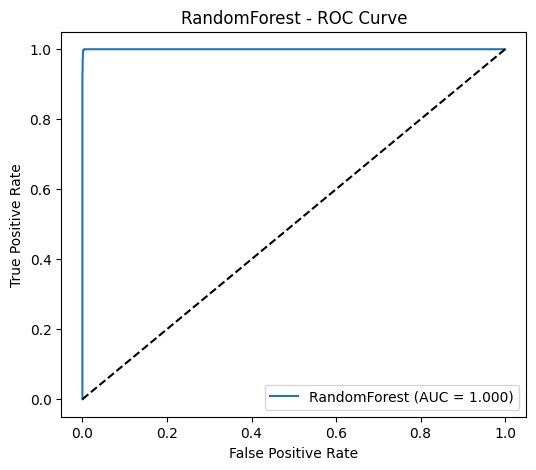

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# 1. Load the ISOT dataset
fake = pd.read_csv("../data/raw/Fake.csv")
true = pd.read_csv("../data/raw/True.csv")

# Add labels: Fake=0, True=1
fake["label"] = 0
true["label"] = 1

# Use title+text as content
df = pd.concat([fake, true], axis=0).sample(frac=1, random_state=42)  # shuffle
df["content"] = df["title"].fillna('') + " " + df["text"].fillna('')

X = df["content"].values
y = df["label"].values

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Define baseline models
models = {
    "MultinomialNB": MultinomialNB(),
    "LogisticRegression": LogisticRegression(max_iter=200, solver="liblinear"),
    "LinearSVM": LinearSVC(),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42)
}

# 3. Evaluate with Confusion Matrix & ROC Curve
for name, model in models.items():
    print(f"\n===== {name} =====")
    
    # Build pipeline
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", max_features=5000)),
        ("clf", model)
    ])
    
    # Fit model
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Classification metrics
    print(classification_report(y_test, y_pred, digits=3))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake","True"], yticklabels=["Fake","True"])
    plt.title(f"{name} - Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()
    
    # ROC Curve
    plt.figure(figsize=(6,5))
    if hasattr(model, "predict_proba"):  # Models that support probability (NB, LR, RF)
        y_scores = pipeline.predict_proba(X_test)[:,1]
    else:  # For LinearSVC, use decision_function
        y_scores = pipeline.decision_function(X_test)
    
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")
    plt.plot([0,1],[0,1],'k--')
    plt.title(f"{name} - ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.show()

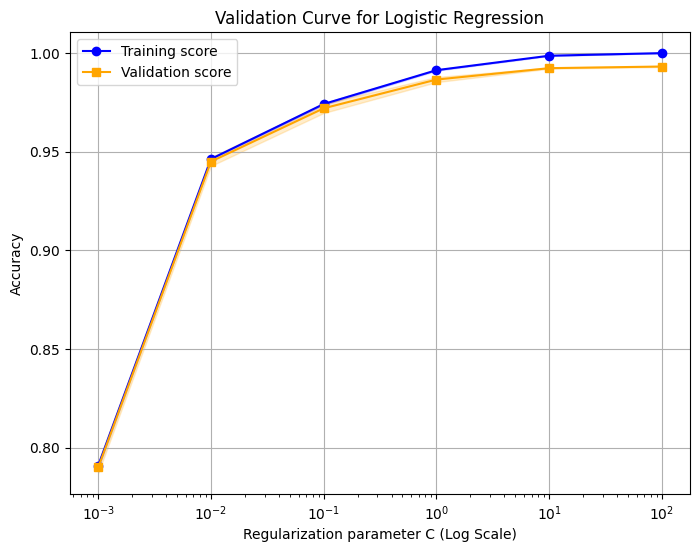

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import validation_curve

# Example: Validation curve for Logistic Regression (C = inverse of regularization strength)

# Build pipeline: TF-IDF + Logistic Regression
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", max_features=5000)),
    ("clf", LogisticRegression(max_iter=200, solver="liblinear"))
])

# Range of C values to test
param_range = np.logspace(-3, 2, 6)  # [0.001, 0.01, 0.1, 1, 10, 100]

# Compute training and validation scores
train_scores, test_scores = validation_curve(
    pipe, X_train, y_train,
    param_name="clf__C",
    param_range=param_range,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Average and std for plotting
train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
test_mean  = np.mean(test_scores, axis=1)
test_std   = np.std(test_scores, axis=1)

# Plot
plt.figure(figsize=(8,6))
plt.plot(param_range, train_mean, label="Training score", color="blue", marker="o")
plt.fill_between(param_range, train_mean-train_std, train_mean+train_std, alpha=0.2, color="blue")

plt.plot(param_range, test_mean, label="Validation score", color="orange", marker="s")
plt.fill_between(param_range, test_mean-test_std, test_mean+test_std, alpha=0.2, color="orange")

plt.xscale("log")
plt.xlabel("Regularization parameter C (Log Scale)")
plt.ylabel("Accuracy")
plt.title("Validation Curve for Logistic Regression")
plt.legend(loc="best")
plt.grid(True)
plt.show()